In [70]:
import numpy as np

np.random.seed(42)

n = 500  # number of observations

# Features
x1 = np.random.uniform(-4, 4, n)
x2 = np.random.uniform(-4, 4, n)

# True parameters
beta0 = -0.5
beta1 = 1.0
beta2 = -0.8

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Probabilities
p = sigmoid(beta0 + beta1*x1 + beta2*x2)

# Binary outcome
y = np.random.binomial(1, p)

# Stack into design matrix
X = np.column_stack((x1, x2))

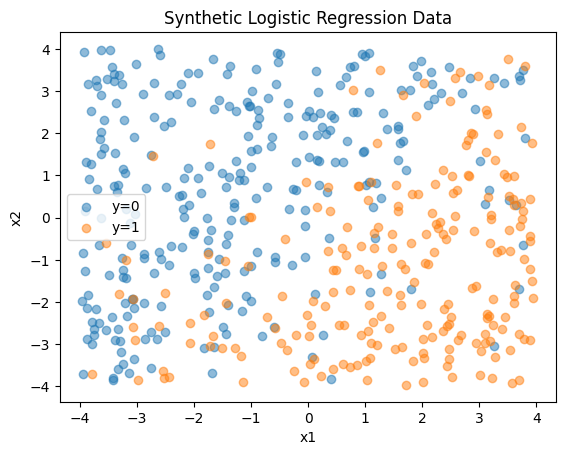

In [71]:
import matplotlib.pyplot as plt

plt.scatter(x1[y==0], x2[y==0], alpha=0.5, label="y=0")
plt.scatter(x1[y==1], x2[y==1], alpha=0.5, label="y=1")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.title("Synthetic Logistic Regression Data")
plt.show()

In [72]:
from sklearn.linear_model import LogisticRegression

# X: (n, 2), y: (n,)
model = LogisticRegression(fit_intercept=True, solver="lbfgs")

model.fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

# Predicted probabilities P(y=1|x)
p_hat = model.predict_proba(X)[:, 1]

# Predicted classes
y_hat = model.predict(X)

Intercept: [-0.57849163]
Coefficients: [[ 0.86544736 -0.71840821]]


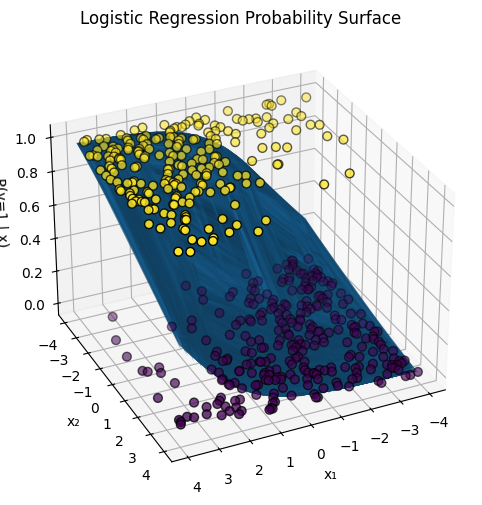

In [73]:

# import the package
from mpl_toolkits.mplot3d import Axes3D

# Logistic parameters
theta0 = model.intercept_[0]
theta1, theta2 = model.coef_[0]



# Grid
X1, X2 = np.meshgrid(x1, x2)

Z = sigmoid(theta0 + theta1*X1 + theta2*X2)

# Plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X1, X2, Z, alpha=0.25,
    linewidth=0,
    antialiased=True)

ax.scatter(
    X[:,0],       # x1
    X[:,1],       # x2
    y,            # raw outcome: 0 or 1
    c=y,          # color by class
    s=40,
    edgecolor='k',
    depthshade=True
)

ax.set_xlabel("x₁")
ax.set_ylabel("x₂")
ax.set_zlabel("P(y=1 | x)")
ax.set_title("Logistic Regression Probability Surface")
ax.view_init(elev=30, azim=65)
plt.show()


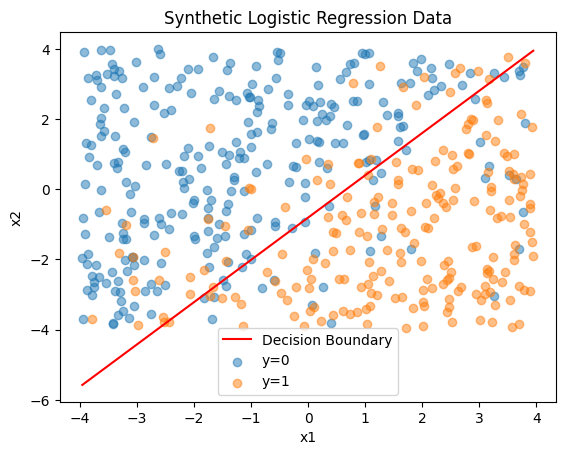

In [74]:

x_vals = np.linspace(min(x1), max(x1), 100)


y_vals = (-theta0 -theta1 * x_vals) / theta2
plt.plot(x_vals, y_vals, color='red', label="Decision Boundary")


plt.scatter(x1[y==0], x2[y==0], alpha=0.5, label="y=0")
plt.scatter(x1[y==1], x2[y==1], alpha=0.5, label="y=1")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.title("Synthetic Logistic Regression Data")
plt.show()

In [97]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


lda = LinearDiscriminantAnalysis()
lda.fit(X, y)



LinearDiscriminantAnalysis()

In [98]:

# Coefficients
w = lda.coef_[0]       # array([w1, w2])
b = lda.intercept_[0]  # scalar



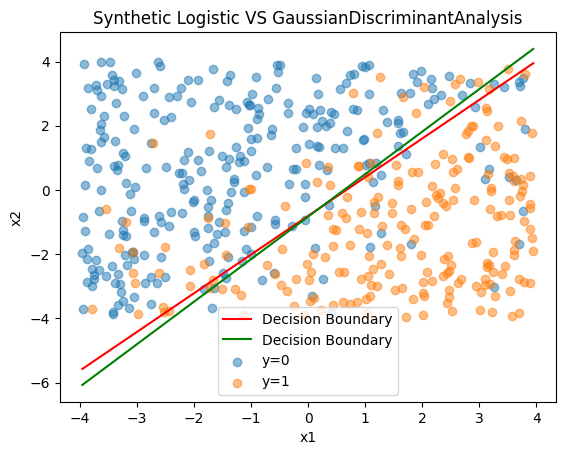

In [101]:
x_vals = np.linspace(min(x1), max(x1), 100)
y_vals = (-theta0 -theta1 * x_vals) / theta2
x_vals1 = np.linspace(min(x1), max(x1), 100)
y_vals1 = -( b + w[0] * x_vals1) / w[1]



plt.plot(x_vals, y_vals, color='red', label="Decision Boundary")
plt.plot(x_vals1, y_vals1, color='green', label="Decision Boundary")


plt.scatter(x1[y==0], x2[y==0], alpha=0.5, label="y=0")
plt.scatter(x1[y==1], x2[y==1], alpha=0.5, label="y=1")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.title("Synthetic Logistic VS GaussianDiscriminantAnalysis")
plt.show()

-0.565153495105114